# V3 피처 전체 분석

**분석 순서**
1. 데이터 로드 & 전처리
2. 기준 모델 학습 → SHAP 중요도 확보
3. VIF + SHAP 결합 반복 제거 → Dataset 2 생성
4. 정제 모델 학습 & Dataset 1 vs Dataset 2 성능 비교
5. XAI 분석 (SHAP / Permutation / Surrogate Tree / Counterfactual)

| 데이터셋 | 설명 |
|---------|------|
| Dataset 1 | V3 원본 (84개 변수) |
| Dataset 2 | VIF+SHAP 결합 반복 제거 후 |

In [29]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score
from sklearn.inspection import permutation_importance
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
import xgboost as xgb
import shap

BASE = Path('../..').resolve()
SEED = 42

df = pd.read_csv(
    BASE / '_data/02_interim/260513 feature/Membership_v4.csv',
    encoding='utf-8-sig'
)
print(f'V4 shape: {df.shape}')
df.head(3)

V4 shape: (23343, 91)


,USER_KEY,product_code,price,billing_method,max_screen,is_promotion,is_churn_prevented,payment_device,is_user_verified,gender,...,family_animation_ratio,drama_ratio,thriller_crime_ratio,sf_fantasy_ratio,comedy_ratio,romance_ratio,horror_ratio,documentary_ratio,historical_war_ratio,other_ratio
0,7a6960912bebe03c6e4c770eb1aa91329c3497f18f90ca...,pk_1489,100.0,134,4.0,1,0,pc,1,F,...,0.003861,0.389961,0.361004,0.0,0.000000,0.013514,0.0,0.0,0.0,0.001931
1,4ec765db76545c1d6dda9f421590bf9d02f584009f8d92...,pk_1487,100.0,190,1.0,1,1,pc,1,F,...,0.000000,0.250000,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000
2,01b16f9f7ff29b48b1ee0d1a89d1eb9662474e5eedb8c2...,pk_1488,100.0,180,2.0,1,0,android,1,F,...,0.000000,0.000000,0.992248,0.0,0.007752,0.000000,0.0,0.0,0.0,0.000000


In [30]:
EXCLUDE = [
    'USER_KEY', 'product_code', 'payment_device',
    'gender', 'reg_date', 'end_date', 'is_repurchase'
]
EXCLUDE = [c for c in EXCLUDE if c in df.columns]

df_enc = df.copy()
for col in df_enc.select_dtypes('object').columns:
    if col not in EXCLUDE:
        df_enc[col] = LabelEncoder().fit_transform(df_enc[col].astype(str))

FEAT1 = [c for c in df_enc.columns if c not in EXCLUDE]
X1    = df_enc[FEAT1].fillna(0)
y     = df_enc['is_repurchase']

print(f'Dataset 1 변수 수: {len(FEAT1)}개')
print(f'이탈(0): {(y==0).sum():,}명 / 재구매(1): {(y==1).sum():,}명')

Dataset 1 변수 수: 84개
이탈(0): 6,641명 / 재구매(1): 16,702명


## 1. 기준 모델 학습 & SHAP 중요도 확인

VIF 제거 시 중요한 변수를 보존하기 위해 **전체 변수로 먼저 모델을 학습**하고 SHAP 중요도를 확보합니다.
이후 VIF가 높은 변수 그룹에서 SHAP 중요도가 낮은 것을 우선 제거합니다.

In [31]:
X_tr1, X_te1, y_tr1, y_te1 = train_test_split(
    X1, y, test_size=0.2, stratify=y, random_state=SEED
)
spw = (y_tr1==0).sum() / (y_tr1==1).sum()

model_base = xgb.XGBClassifier(
    n_estimators=500, learning_rate=0.05, max_depth=6,
    scale_pos_weight=spw, subsample=0.8, colsample_bytree=0.8,
    eval_metric='logloss', early_stopping_rounds=50,
    random_state=SEED, n_jobs=-1, verbosity=0
)
model_base.fit(X_tr1, y_tr1, eval_set=[(X_te1, y_te1)], verbose=False)

y_pred1  = model_base.predict(X_te1)
y_proba1 = model_base.predict_proba(X_te1)[:,1]
print(f'[기준 모델] AUC={roc_auc_score(y_te1, y_proba1):.4f}  '
      f'F1={f1_score(y_te1, y_pred1):.4f}  변수={len(FEAT1)}개')

explainer_base = shap.TreeExplainer(model_base)
shap_base      = explainer_base.shap_values(X_te1)

shap_importance = pd.DataFrame({
    '변수': FEAT1,
    'SHAP': np.abs(shap_base).mean(axis=0)
}).sort_values('SHAP', ascending=False).reset_index(drop=True)
shap_importance.index += 1

print('\n=== SHAP 중요도 (상위 20) ===')
print(shap_importance.head(20).to_string())

[기준 모델] AUC=0.8842  F1=0.8567  변수=84개

=== SHAP 중요도 (상위 20) ===
                        변수      SHAP
1       retention_w2_ratio  0.410578
2       watch_time(min)_w3  0.405341
3       retention_w3_ratio  0.352366
4              drama_ratio  0.347255
5   family_animation_ratio  0.329571
6             is_promotion  0.314593
7         is_cold_start_3d  0.304247
8            romance_ratio  0.298183
9     thriller_crime_ratio  0.273138
10  action_adventure_ratio  0.242608
11      diff_between_w2_w1  0.220058
12      diff_between_w3_w2  0.179803
13  median_watch_time(min)  0.157243
14              max_screen  0.152560
15     max_watch_time(min)  0.126161
16      is_churn_prevented  0.123573
17      diff_between_w3_w1  0.117314
18           max_day_share  0.113715
19   genre_diversity_count  0.094894
20     std_watch_time(min)  0.088651


## 2. VIF + SHAP 결합 반복 제거 → Dataset 2 생성

**알고리즘:**
1. 전체 변수에 대해 VIF 계산
2. VIF > 임계값인 변수 그룹 중 **SHAP 중요도가 가장 낮은 변수 1개** 제거
3. VIF 재계산 → 임계값 이하 도달 시 종료

같은 정보를 담고 있는 변수 쌍에서 덜 중요한 것이 자동으로 선택되어 제거됩니다.

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

VIF_THRESHOLD = 10

def calc_vif(X_df):
    Xv = X_df.select_dtypes(include=[np.number]).copy()
    Xv = Xv.drop(columns=[c for c in Xv.columns if Xv[c].var() == 0])
    Xv.insert(0, 'const', 1)
    vals = Xv.values.astype(float)
    result = []
    for i in range(1, len(Xv.columns)):
        try:
            v = variance_inflation_factor(vals, i)
        except Exception:
            v = np.inf
        result.append({'변수': Xv.columns[i], 'VIF': v})
    return pd.DataFrame(result)

shap_dict = dict(zip(shap_importance['변수'], shap_importance['SHAP']))

FEAT2       = FEAT1.copy()
removed_log = []
print(f'시작: {len(FEAT2)}개 변수 | VIF 임계값: {VIF_THRESHOLD}\n')

while True:
    vif_df   = calc_vif(X1[FEAT2])
    high_vif = vif_df[np.isinf(vif_df['VIF']) | (vif_df['VIF'] > VIF_THRESHOLD)].copy()

    if len(high_vif) == 0:
        print(f'\n완료! 모든 변수 VIF <= {VIF_THRESHOLD}  (최종 변수: {len(FEAT2)}개)')
        break

    high_vif['SHAP'] = high_vif['변수'].map(shap_dict).fillna(0)
    target   = high_vif.sort_values('SHAP').iloc[0]
    vif_str  = 'inf' if np.isinf(target['VIF']) else f"{target['VIF']:.1f}"

    FEAT2.remove(target['변수'])
    step = len(removed_log) + 1
    removed_log.append({
        'step': step, '제거변수': target['변수'],
        'VIF': vif_str, 'SHAP': round(target['SHAP'], 4),
        '잔여변수': len(FEAT2)
    })
    print(f"[{step:2d}] 제거: {target['변수']:<38}  "
          f"VIF={vif_str:>8}  SHAP={target['SHAP']:.4f}  남은: {len(FEAT2)}개")

X2 = X1[FEAT2]
print(f'\nDataset 1: {len(FEAT1)}개 -> Dataset 2: {len(FEAT2)}개  ({len(FEAT1)-len(FEAT2)}개 제거)')
print('\n=== 제거 로그 ===')
print(pd.DataFrame(removed_log).to_string(index=False))

# ── 최종 VIF 검증 ──────────────────────────────────────────────────────────────
print('\n=== 최종 VIF 검증 (잔류 변수 전체) ===')
final_vif = calc_vif(X2).sort_values('VIF', ascending=False).reset_index(drop=True)
final_vif['위험도'] = final_vif['VIF'].apply(lambda v: '주의(5~10)' if v > 5 else '양호')
print(final_vif.to_string())
print(f'\nVIF 최대값: {final_vif["VIF"].max():.2f}  /  평균: {final_vif["VIF"].mean():.2f}')

## 3. 정제 모델 학습 & 성능 비교

[Dataset1: V3 원본]  AUC=0.8827  F1=0.8541  변수=84개
[Dataset2: VIF+SHAP 정제]  AUC=0.8826  F1=0.8526  변수=63개

=== 최종 성능 비교 ===
                   모델  변수 수  AUC-ROC     F1  Precision  Recall
      Dataset1: V3 원본    84   0.8827 0.8541     0.8972  0.8150
Dataset2: VIF+SHAP 정제    63   0.8826 0.8526     0.8985  0.8111


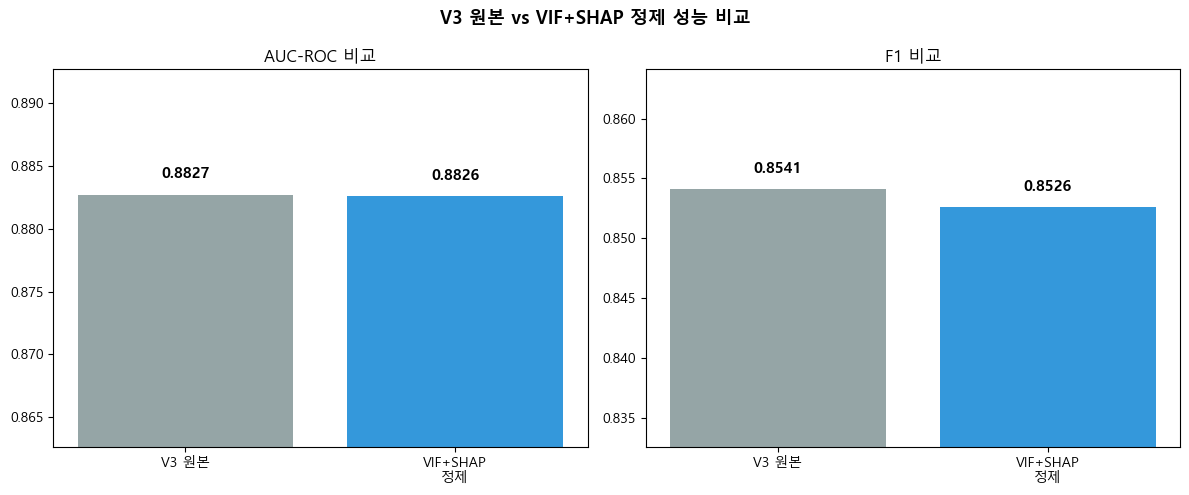


[최종 모델] AUC=0.8826  변수=63개  (XAI 분석에 사용)


In [ ]:
def train_eval(X, y_all, label):
    Xtr, Xte, ytr, yte = train_test_split(
        X, y_all, test_size=0.2, stratify=y_all, random_state=SEED
    )
    spw_i = (ytr==0).sum() / (ytr==1).sum()
    m = xgb.XGBClassifier(
        n_estimators=500, learning_rate=0.05, max_depth=6,
        scale_pos_weight=spw_i, subsample=0.8, colsample_bytree=0.8,
        eval_metric='logloss', early_stopping_rounds=50,
        random_state=SEED, n_jobs=-1, verbosity=0
    )
    m.fit(Xtr, ytr, eval_set=[(Xte, yte)], verbose=False)
    yp  = m.predict(Xte)
    ypr = m.predict_proba(Xte)[:,1]
    r = {
        '모델': label, '변수 수': X.shape[1],
        'AUC-ROC':   round(roc_auc_score(yte, ypr), 4),
        'F1':        round(f1_score(yte, yp), 4),
        'Precision': round(precision_score(yte, yp), 4),
        'Recall':    round(recall_score(yte, yp), 4),
    }
    print(f'[{label}]  AUC={r["AUC-ROC"]:.4f}  F1={r["F1"]:.4f}  변수={X.shape[1]}개')
    return r

results   = [train_eval(X1, y, 'Dataset1: V3 원본'),
             train_eval(X2, y, 'Dataset2: VIF+SHAP 정제')]
result_df = pd.DataFrame(results)

print('\n=== 최종 성능 비교 ===')
print(result_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, metric in zip(axes, ['AUC-ROC', 'F1']):
    vals = result_df[metric].tolist()
    bars = ax.bar(range(2), vals, color=['#95a5a6', '#3498db'])
    ax.set_title(f'{metric} 비교')
    ax.set_xticks(range(2))
    ax.set_xticklabels(['V3 원본', 'VIF+SHAP\n정제'])
    ax.set_ylim(max(0, min(vals)-0.02), max(vals)+0.01)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001,
                f'{val:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
plt.suptitle('V3 원본 vs VIF+SHAP 정제 성능 비교', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

X_tr2, X_te2, y_tr2, y_te2 = train_test_split(
    X2, y, test_size=0.2, stratify=y, random_state=SEED
)
spw2 = (y_tr2==0).sum() / (y_tr2==1).sum()
model_final = xgb.XGBClassifier(
    n_estimators=500, learning_rate=0.05, max_depth=6,
    scale_pos_weight=spw2, subsample=0.8, colsample_bytree=0.8,
    eval_metric='logloss', early_stopping_rounds=50,
    random_state=SEED, n_jobs=-1, verbosity=0
)
model_final.fit(X_tr2, y_tr2, eval_set=[(X_te2, y_te2)], verbose=False)
print(f'\n[최종 모델] AUC={roc_auc_score(y_te2, model_final.predict_proba(X_te2)[:,1]):.4f}  '
      f'변수={len(FEAT2)}개  (XAI 분석에 사용)')

## 4. XAI 분석 (정제 모델 기준)
### 4-1. SHAP

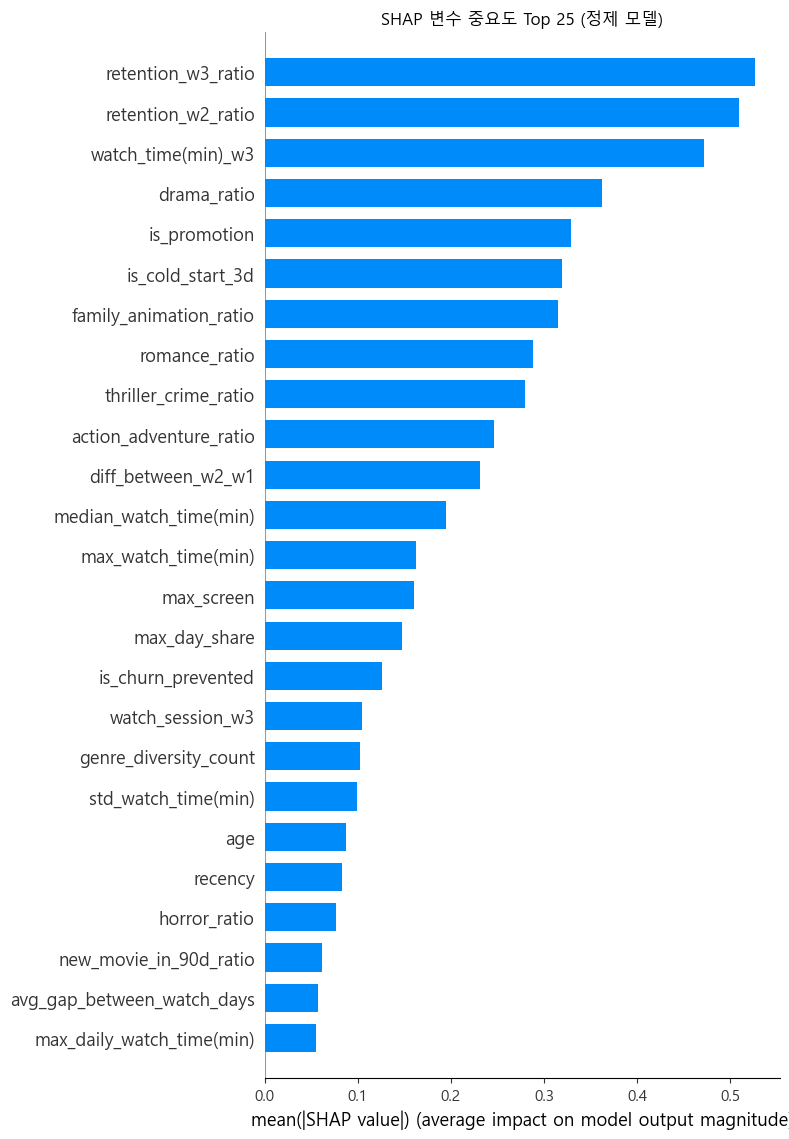

=== SHAP 중요도 (상위 25) ===
                            변수      SHAP
1           retention_w3_ratio  0.526941
2           retention_w2_ratio  0.509289
3           watch_time(min)_w3  0.471718
4                  drama_ratio  0.362168
5                 is_promotion  0.329133
6             is_cold_start_3d  0.318810
7       family_animation_ratio  0.314597
8                romance_ratio  0.287621
9         thriller_crime_ratio  0.279155
10      action_adventure_ratio  0.246355
11          diff_between_w2_w1  0.231576
12      median_watch_time(min)  0.195143
13         max_watch_time(min)  0.162272
14                  max_screen  0.160198
15               max_day_share  0.147674
16          is_churn_prevented  0.126029
17            watch_session_w3  0.104937
18       genre_diversity_count  0.102075
19         std_watch_time(min)  0.099460
20                         age  0.087246
21                     recency  0.083611
22                horror_ratio  0.076198
23      new_movie_in_90d_ratio  

In [ ]:
explainer_final = shap.TreeExplainer(model_final)
shap_final      = explainer_final.shap_values(X_te2)

shap_df = pd.DataFrame({
    '변수': FEAT2,
    'SHAP': np.abs(shap_final).mean(axis=0)
}).sort_values('SHAP', ascending=False).reset_index(drop=True)
shap_df.index += 1

plt.figure(figsize=(10, 9))
shap.summary_plot(shap_final, X_te2, plot_type='bar', show=False, max_display=25)
plt.title('SHAP 변수 중요도 Top 25 (정제 모델)')
plt.tight_layout(); plt.show()

print('=== SHAP 중요도 (상위 25) ===')
print(shap_df.head(25).to_string())

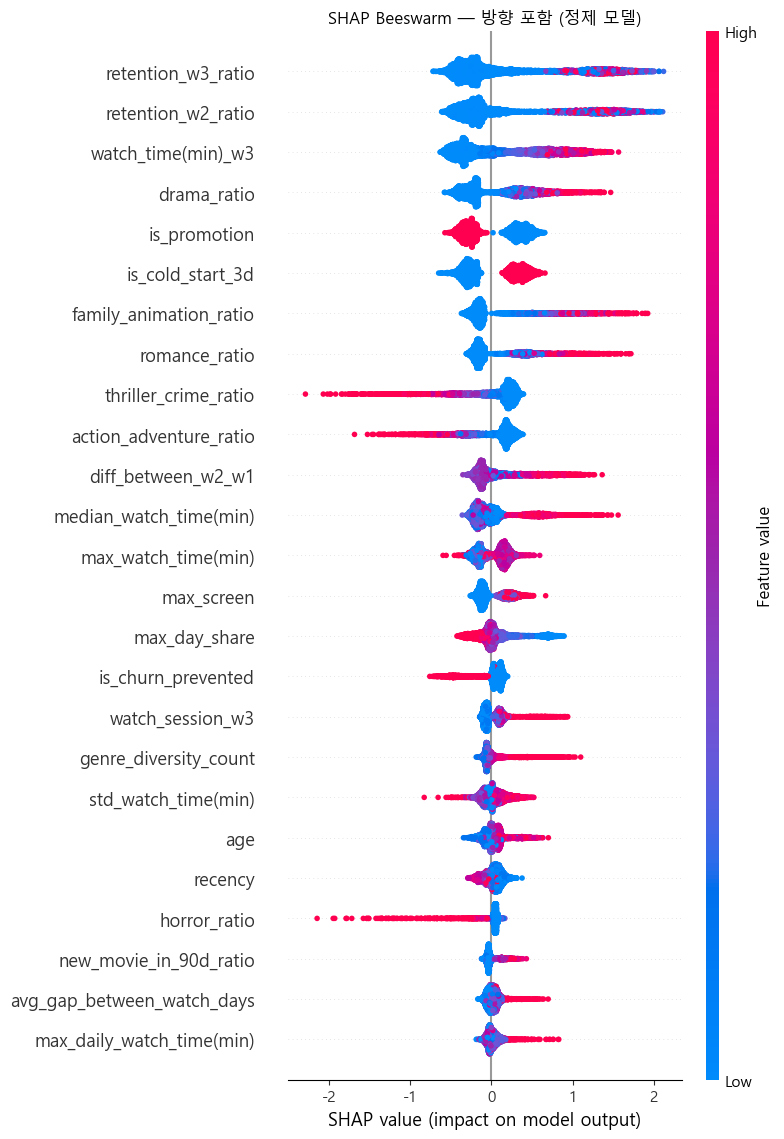

In [ ]:
plt.figure(figsize=(10, 9))
shap.summary_plot(shap_final, X_te2, show=False, max_display=25)
plt.title('SHAP Beeswarm — 방향 포함 (정제 모델)')
plt.tight_layout(); plt.show()

### 4-1-1. 프로모션 그룹별 SHAP 비교

`is_promotion=0` vs `is_promotion=1` 그룹을 나눠 SHAP 중요도를 비교합니다.
두 그룹에서 중요한 변수가 다르면 이탈 패턴 자체가 다른 것입니다.

In [ ]:
prom_col = 'is_promotion' if 'is_promotion' in FEAT2 else None

if prom_col is None:
    print('is_promotion이 Dataset 2에 없습니다. (VIF 단계에서 제거됨)')
else:
    mask0 = X_te2[prom_col] == 0
    mask1 = X_te2[prom_col] == 1
    print(f'프로모션=0: {mask0.sum()}명 / 프로모션=1: {mask1.sum()}명')

    shap0 = explainer_final.shap_values(X_te2[mask0])
    shap1 = explainer_final.shap_values(X_te2[mask1])

    imp0 = pd.DataFrame({'변수': FEAT2, 'SHAP': np.abs(shap0).mean(axis=0)}).sort_values('SHAP', ascending=False).reset_index(drop=True)
    imp1 = pd.DataFrame({'변수': FEAT2, 'SHAP': np.abs(shap1).mean(axis=0)}).sort_values('SHAP', ascending=False).reset_index(drop=True)

    # ── 시각화: 두 그룹 Top15 나란히 ─────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    for ax, imp, title, color in zip(
        axes,
        [imp0, imp1],
        ['프로모션=0 (일반 가입) Top 15', '프로모션=1 (프로모션 가입) Top 15'],
        ['#3498db', '#e74c3c']
    ):
        top = imp.head(15).sort_values('SHAP')
        ax.barh(top['변수'], top['SHAP'], color=color)
        ax.set_title(title, fontsize=12)
        ax.set_xlabel('평균 |SHAP|')
    plt.suptitle('프로모션 그룹별 SHAP 중요도 비교', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()

    # ── 수치 비교: 두 그룹 차이가 큰 변수 순 ────────────────────────────────
    comp = pd.DataFrame({
        '변수':        FEAT2,
        '비프로모션(0)': np.abs(shap0).mean(axis=0),
        '프로모션(1)':   np.abs(shap1).mean(axis=0),
    })
    comp['차이(1-0)'] = comp['프로모션(1)'] - comp['비프로모션(0)']
    comp = comp.sort_values('차이(1-0)', key=abs, ascending=False).reset_index(drop=True)
    comp.index += 1
    print('\n=== 그룹 간 SHAP 차이 (절대값 큰 순서) ===')
    print('양수: 프로모션 그룹에서 더 중요 / 음수: 비프로모션 그룹에서 더 중요\n')
    print(comp.head(20).to_string())

### 4-2. Permutation Importance

=== Permutation Importance ===
                        변수  AUC감소(평균)      표준편차
1       retention_w3_ratio   0.050045  0.003782
2       retention_w2_ratio   0.049391  0.003358
3       watch_time(min)_w3   0.022840  0.001336
4              drama_ratio   0.016566  0.001328
5   family_animation_ratio   0.015435  0.001420
6     thriller_crime_ratio   0.013605  0.000923
7            max_day_share   0.011907  0.000775
8            romance_ratio   0.011838  0.001404
9         is_cold_start_3d   0.010857  0.001214
10  action_adventure_ratio   0.008965  0.001000
11  median_watch_time(min)   0.008460  0.000967
12            is_promotion   0.008354  0.000891
13      diff_between_w2_w1   0.007070  0.001324
14              max_screen   0.002558  0.000643
15      is_churn_prevented   0.002053  0.000814
16            horror_ratio   0.002043  0.000578
17     max_watch_time(min)   0.002000  0.000415
18   genre_diversity_count   0.001364  0.000524
19        sf_fantasy_ratio   0.001152  0.000297
20       

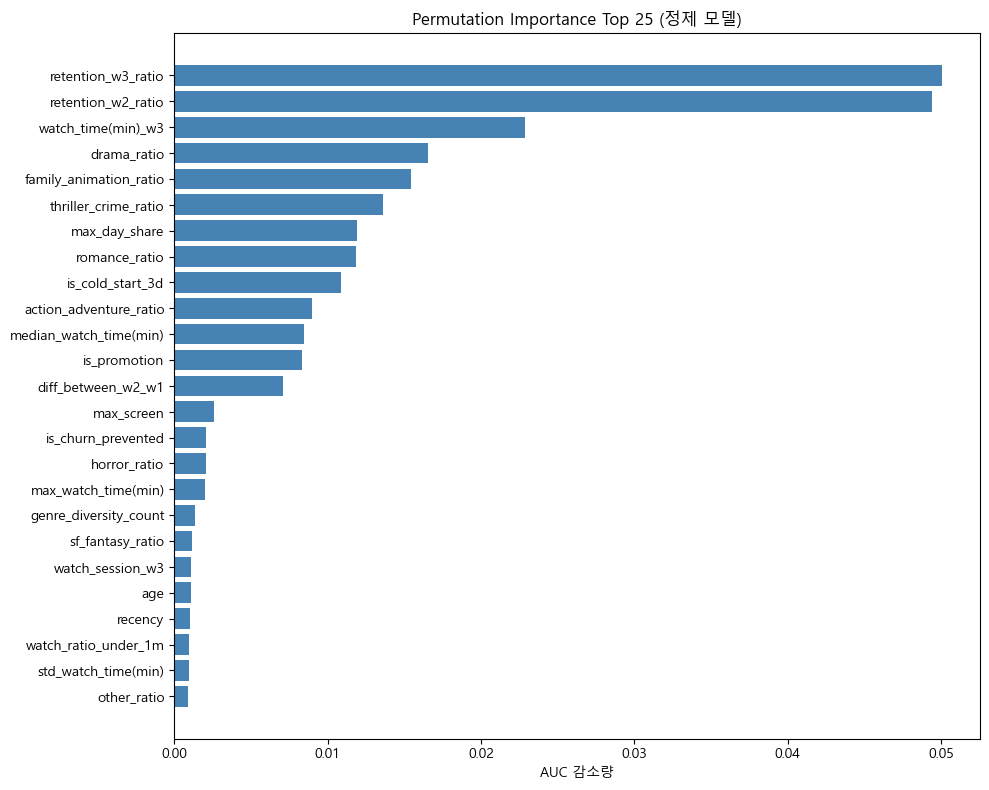

In [ ]:
perm = permutation_importance(
    model_final, X_te2, y_te2,
    n_repeats=10, random_state=SEED, scoring='roc_auc', n_jobs=-1
)
perm_df = pd.DataFrame({
    '변수': FEAT2,
    'AUC감소(평균)': perm.importances_mean,
    '표준편차':      perm.importances_std,
}).sort_values('AUC감소(평균)', ascending=False).reset_index(drop=True)
perm_df.index += 1

print('=== Permutation Importance ===')
print(perm_df.head(25).to_string())

fig, ax = plt.subplots(figsize=(10, 8))
top = perm_df.head(25)
ax.barh(top['변수'][::-1], top['AUC감소(평균)'][::-1], color='steelblue')
ax.set_title('Permutation Importance Top 25 (정제 모델)')
ax.set_xlabel('AUC 감소량')
plt.tight_layout(); plt.show()

### 4-3. Surrogate Tree (규칙 추출)

=== Surrogate Tree 규칙 ===
|--- watch_time(min)_w3 <= 4.50
|   |--- diff_between_w2_w1 <= 5.50
|   |   |--- max_day_share <= 0.73
|   |   |   |--- is_promotion <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- is_promotion >  0.50
|   |   |   |   |--- class: 0
|   |   |--- max_day_share >  0.73
|   |   |   |--- max_watch_time(min) <= 81.50
|   |   |   |   |--- class: 0
|   |   |   |--- max_watch_time(min) >  81.50
|   |   |   |   |--- class: 0
|   |--- diff_between_w2_w1 >  5.50
|   |   |--- diff_between_w2_w1 <= 76.50
|   |   |   |--- drama_ratio <= 0.00
|   |   |   |   |--- class: 0
|   |   |   |--- drama_ratio >  0.00
|   |   |   |   |--- class: 1
|   |   |--- diff_between_w2_w1 >  76.50
|   |   |   |--- thriller_crime_ratio <= 0.53
|   |   |   |   |--- class: 1
|   |   |   |--- thriller_crime_ratio >  0.53
|   |   |   |   |--- class: 0
|--- watch_time(min)_w3 >  4.50
|   |--- watch_time(min)_w3 <= 91.50
|   |   |--- drama_ratio <= 0.00
|   |   |   |--- family_animation_ratio <=

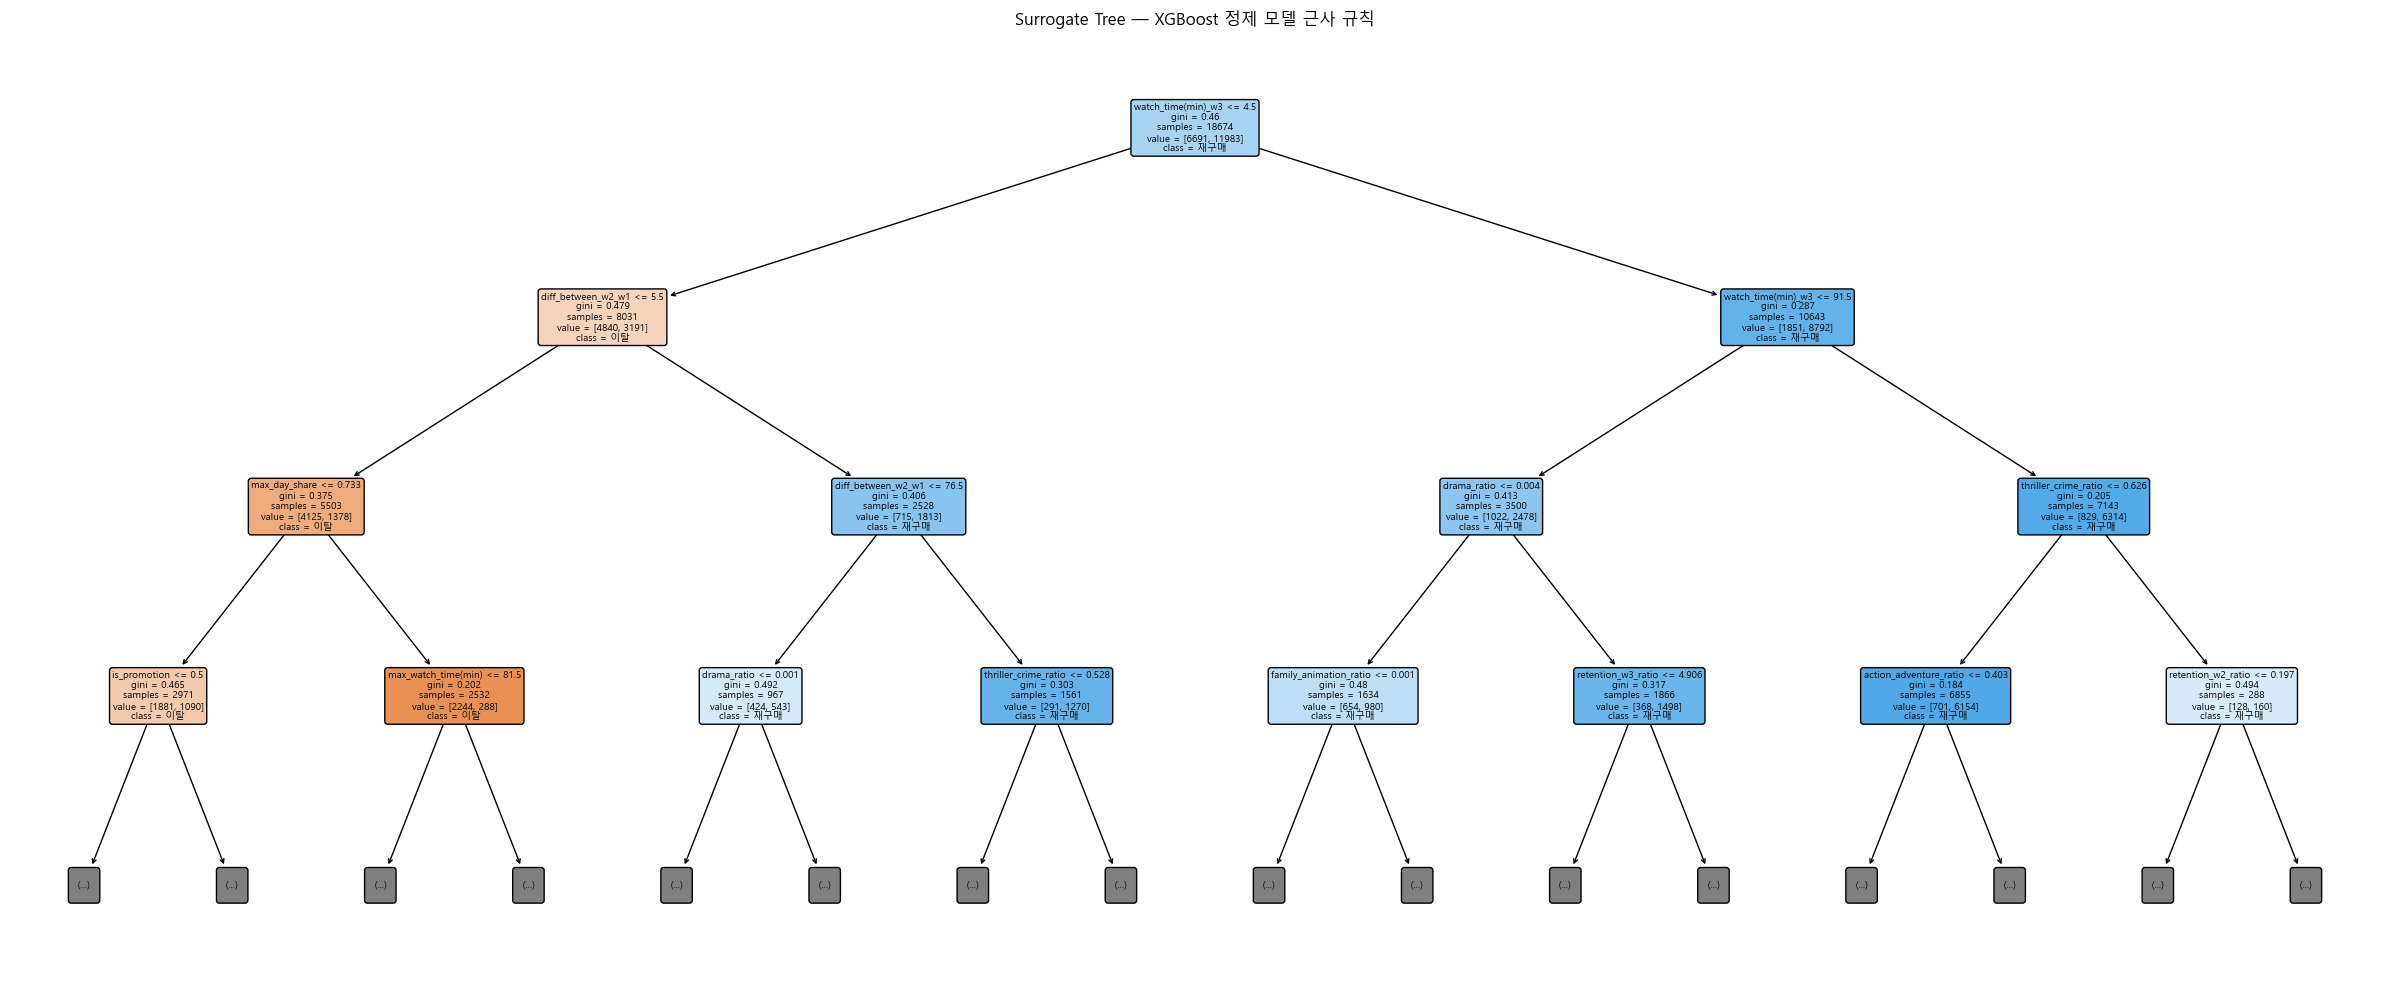

In [ ]:
y_pred_train2 = (model_final.predict_proba(X_tr2)[:,1] > 0.5).astype(int)

surrogate = DecisionTreeClassifier(max_depth=4, random_state=SEED)
surrogate.fit(X_tr2, y_pred_train2)

print('=== Surrogate Tree 규칙 ===')
print(export_text(surrogate, feature_names=list(FEAT2), max_depth=4))

fig, ax = plt.subplots(figsize=(24, 10))
plot_tree(surrogate, feature_names=list(FEAT2),
          class_names=['이탈', '재구매'],
          filled=True, rounded=True, ax=ax, max_depth=3, fontsize=7)
plt.title('Surrogate Tree — XGBoost 정제 모델 근사 규칙')
plt.tight_layout(); plt.show()

### 4-4. Counterfactual Explanation

선택 고객 재구매 확률: 1.1%

=== Counterfactual ===
                 변경 변수  원래 값  변경 값(Q75)  원래 확률  변경 후 확률  확률 변화
    watch_time(min)_w3   0.0     140.00  0.011    0.045  0.034
    retention_w3_ratio   1.0       4.00  0.011    0.026  0.015
    retention_w2_ratio   0.0       3.57  0.011    0.026  0.015
         romance_ratio   0.0       0.06  0.011    0.024  0.013
  thriller_crime_ratio   1.0       0.16  0.011    0.020  0.009
           drama_ratio   0.0       0.26  0.011    0.018  0.007
action_adventure_ratio   0.0       0.08  0.011    0.012  0.001
          is_promotion   1.0       1.00  0.011    0.011  0.000
      is_cold_start_3d   1.0       1.00  0.011    0.011  0.000
family_animation_ratio   0.0       0.00  0.011    0.011  0.000


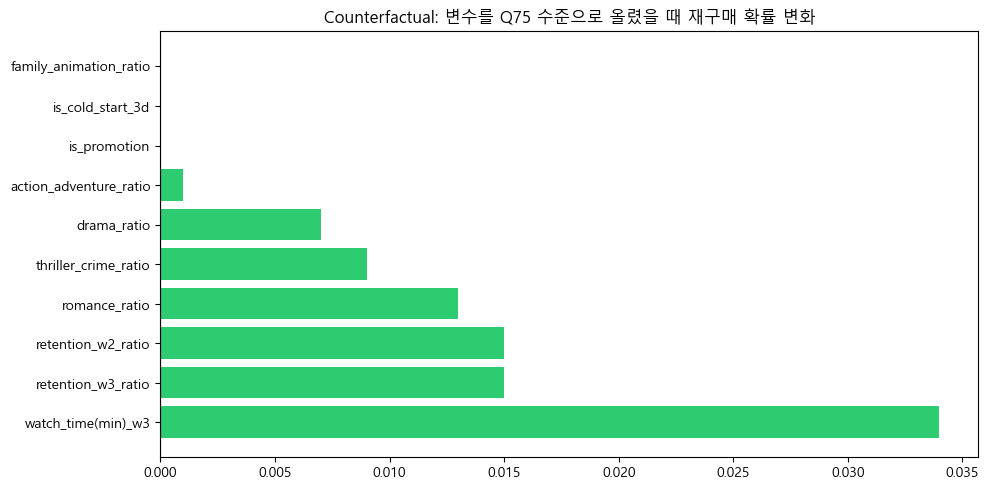

In [ ]:
y_pred_test2 = model_final.predict_proba(X_te2)[:,1]
churn_mask   = (y_pred_test2 < 0.4) & (y_te2.values == 0)
churn_idx    = np.where(churn_mask)[0]
top_idx      = churn_idx[np.argsort(y_pred_test2[churn_idx])[0]]
churn_user   = X_te2.iloc[top_idx]
base_prob    = model_final.predict_proba(churn_user.values.reshape(1, -1))[0, 1]
print(f'선택 고객 재구매 확률: {base_prob:.1%}')

key_feats = shap_df['변수'].head(10).tolist()
rows = []
for feat in key_feats:
    curr_val = churn_user[feat]
    q75      = X_te2[feat].quantile(0.75)
    cf_user  = churn_user.copy()
    cf_user[feat] = q75
    cf_prob  = model_final.predict_proba(cf_user.values.reshape(1, -1))[0, 1]
    rows.append({
        '변경 변수':    feat,
        '원래 값':      round(curr_val, 2),
        '변경 값(Q75)': round(q75, 2),
        '원래 확률':    round(base_prob, 3),
        '변경 후 확률': round(cf_prob, 3),
        '확률 변화':    round(cf_prob - base_prob, 3),
    })

cf_df = pd.DataFrame(rows).sort_values('확률 변화', ascending=False)
print('\n=== Counterfactual ===')
print(cf_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in cf_df['확률 변화']]
ax.barh(cf_df['변경 변수'], cf_df['확률 변화'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Counterfactual: 변수를 Q75 수준으로 올렸을 때 재구매 확률 변화')
plt.tight_layout(); plt.show()